<a href="https://colab.research.google.com/github/VivianneFerreira/Challenge_Alura_Store/blob/main/Challenge_Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Atividades para realizar nesta primeira etapa:

1. Importar os dados;
2. Compreender quais informações o dataset possui;
3. Verificar as incosistencias;
4. Corrigir as incossistencias;
5. Traduzir as colunas e/ou dados;
6. Criar coluna de contas diarias

#📌 Extração

In [77]:
import requests
import pandas as pd

In [78]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [79]:
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65



🔍 **Análise da Estrutura dos Dados**
Os dados são organizados em um formato hierárquico (dicionário dentro de dicionário), contendo as seguintes informações:

1. **Identificação do Cliente**  
   - `'customerID'`: Identificador único do cliente.  
   - `'Churn'`: Indica se o cliente cancelou o serviço (`Yes` ou `No`).  

2. **Informações do Cliente** (`'customer'`)  
   - `'gender'`: Gênero do cliente (`Male` ou `Female`).  
   - `'SeniorCitizen'`: Indica se o cliente é idoso (0 = Não, 1 = Sim).  
   - `'Partner'`: Se o cliente tem um parceiro(a).  
   - `'Dependents'`: Se o cliente tem dependentes.  
   - `'tenure'`: Tempo de permanência como cliente (em meses).  

3. **Serviços de Telefonia** (`'phone'`)  
   - `'PhoneService'`: Indica se o cliente possui serviço de telefone (`Yes` ou `No`).  
   - `'MultipleLines'`: Se possui múltiplas linhas telefônicas.  

4. **Serviços de Internet** (`'internet'`)  
   - Tipo de serviço de internet contratado (`DSL`, `Fiber optic`, `No`).  
   - Serviços adicionais (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`).  

5. **Informações da Conta** (`'account'`)  
   - `'Contract'`: Tipo de contrato (`Month-to-month`, `One year`, `Two year`).  
   - `'PaperlessBilling'`: Se o cliente recebe faturas eletrônicas.  
   - `'PaymentMethod'`: Método de pagamento (`Bank transfer`, `Credit card`, `Electronic check`, `Mailed check`).  
   - `'Charges'`:  
     - `'Monthly'`: Valor mensal cobrado.  
     - `'Total'`: Valor total pago pelo cliente.  



#🔧 Transformacão

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

**VERIFICAÇÕES**

1. Verificando valores unicos

In [81]:
for col in df.columns:
  print(f'{col}: {df[col].unique()}')
  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 50)

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn: ['No' 'Yes' '']
['No' 'Yes' '']
--------------------------------------------------
customer.gender: ['Female' 'Male']
['Female' 'Male']
--------------------------------------------------
customer.SeniorCitizen: [0 1]
[0 1]
--------------------------------------------------
customer.Partner: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
customer.Dependents: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
customer.tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
phone.MultipleLines: ['No' 'Yes' 'No phone service']
['No' 'Yes' 'No phone service']
------

2.Valores Duplicados

In [82]:
print("Numero de duplicados", df.duplicated().sum())

Numero de duplicados 0


3. Valores nulos

In [83]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


4. Vazios ou em branco

In [84]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


**TRANSFORMAÇÕES**

1. Alterando a coluna "account.Charges.Total" para Float

In [85]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')


In [86]:
df= df[df['Churn'].str.strip() != '']
print("Número de filas depois de eliminar as vazias em 'Churn':", len(df))

Número de filas depois de eliminar as vazias em 'Churn': 7043


3.Verificação de vazias ou em branco

In [87]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [88]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [89]:
df = df.dropna(subset=['account.Charges.Total'])

In [90]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


___________OPCIONAL_____

In [91]:
df['contas_diarias'] = df['account.Charges.Monthly'] / 30
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


_____________Padronização__________

In [92]:
colunas = {                                                                # Dicionário com os novos nomes das colunas.
    'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tem +60',
    'customer.Partner': 'possui_parceiro',
    'customer.Dependents': 'possui_dependentes',
    'customer.tenure': 'tempo_contrato',
    'phone.PhoneService': 'servico_telefone',
    'phone.MultipleLines': 'multiplas_linhas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguranca_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'protecao_dispositivo',
    'internet.TechSupport': 'suporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_filmes',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'fatura_digital',
    'account.PaymentMethod': 'metodo_pagamento',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns= colunas)
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


__________Padronizar em portugues______

In [93]:
df['Churn'] = df['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})
df['genero'] = df['genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df['possui_parceiro'] = df['possui_parceiro'].replace({'Yes': 'Sim', 'No': 'Não'})
df['possui_dependentes'] = df['possui_dependentes'].replace({'Yes': 'Sim', 'No': 'Não'})
df['servico_telefone'] = df['servico_telefone'].replace({'Yes': 'Sim', 'No': 'Não'})
df['multiplas_linhas'] = df['multiplas_linhas'].replace({'No': 'Não', 'Yes': 'Sim', 'No phone service': 'Sem serviço de telefone'})
df['tipo_internet'] = df['tipo_internet'].replace({'No': 'Não'})
df.head()

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [94]:
columns_to_translate = ['seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes']
mapping = {'No': 'Não', 'Yes': 'Sim', 'No internet service': 'Sem serviço de internet'}
for col in columns_to_translate:
    df[col] = df[col].replace(mapping)

In [95]:
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensal', 'Two year': 'Bienal'})

In [96]:
df['fatura_digital'] = df['fatura_digital'].replace({'Yes': 'Sim', 'No': 'Não'})

In [97]:
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque enviado',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)',
    'Bank transfer (automatic)': 'Transferência bancária (automática)'
})

In [98]:
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.60,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.90,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Não,Feminino,0,Não,Não,13,Sim,Não,DSL,...,Não,Sim,Não,Não,Anual,Não,Cheque enviado,55.15,742.90,1.838333
7263,9992-RRAMN,Sim,Masculino,0,Sim,Não,22,Sim,Sim,Fiber optic,...,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.70,2.836667
7264,9992-UJOEL,Não,Masculino,0,Não,Não,2,Sim,Não,DSL,...,Não,Não,Não,Não,Mensal,Sim,Cheque enviado,50.30,92.75,1.676667
7265,9993-LHIEB,Não,Masculino,0,Sim,Sim,67,Sim,Não,DSL,...,Sim,Sim,Não,Sim,Bienal,Não,Cheque enviado,67.85,4627.65,2.261667


#📊 Carregamento

1.Analise Descritiva

In [99]:
df.describe()

,tem +60,tempo_contrato,valor_mensal,total_cobrado,contas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


2. Distribuição de Evasão

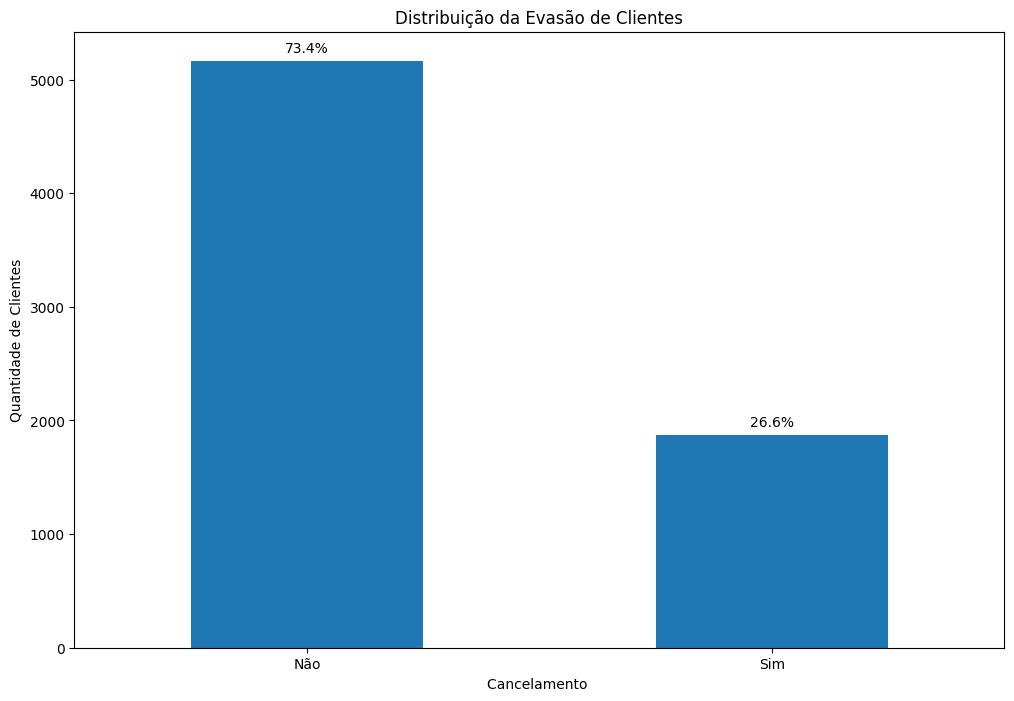

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
churn_counts = df['Churn'].value_counts()
churn_percentages = (churn_counts / len(df)) * 100

ax = churn_counts.plot(kind='bar')
plt.title('Distribuição da Evasão de Clientes')
plt.xlabel('Cancelamento ')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)

for i, percentage in enumerate(churn_percentages):
    ax.text(i, churn_counts.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va='bottom')

plt.show()

3. Contagem de Evasão por Variáveis Categóricas.

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7032 non-null   object 
 1   Churn                 7032 non-null   object 
 2   genero                7032 non-null   object 
 3   tem +60               7032 non-null   int64  
 4   possui_parceiro       7032 non-null   object 
 5   possui_dependentes    7032 non-null   object 
 6   tempo_contrato        7032 non-null   int64  
 7   servico_telefone      7032 non-null   object 
 8   multiplas_linhas      7032 non-null   object 
 9   tipo_internet         7032 non-null   object 
 10  seguranca_online      7032 non-null   object 
 11  backup_online         7032 non-null   object 
 12  protecao_dispositivo  7032 non-null   object 
 13  suporte_tecnico       7032 non-null   object 
 14  streaming_tv          7032 non-null   object 
 15  streaming_filmes      7032

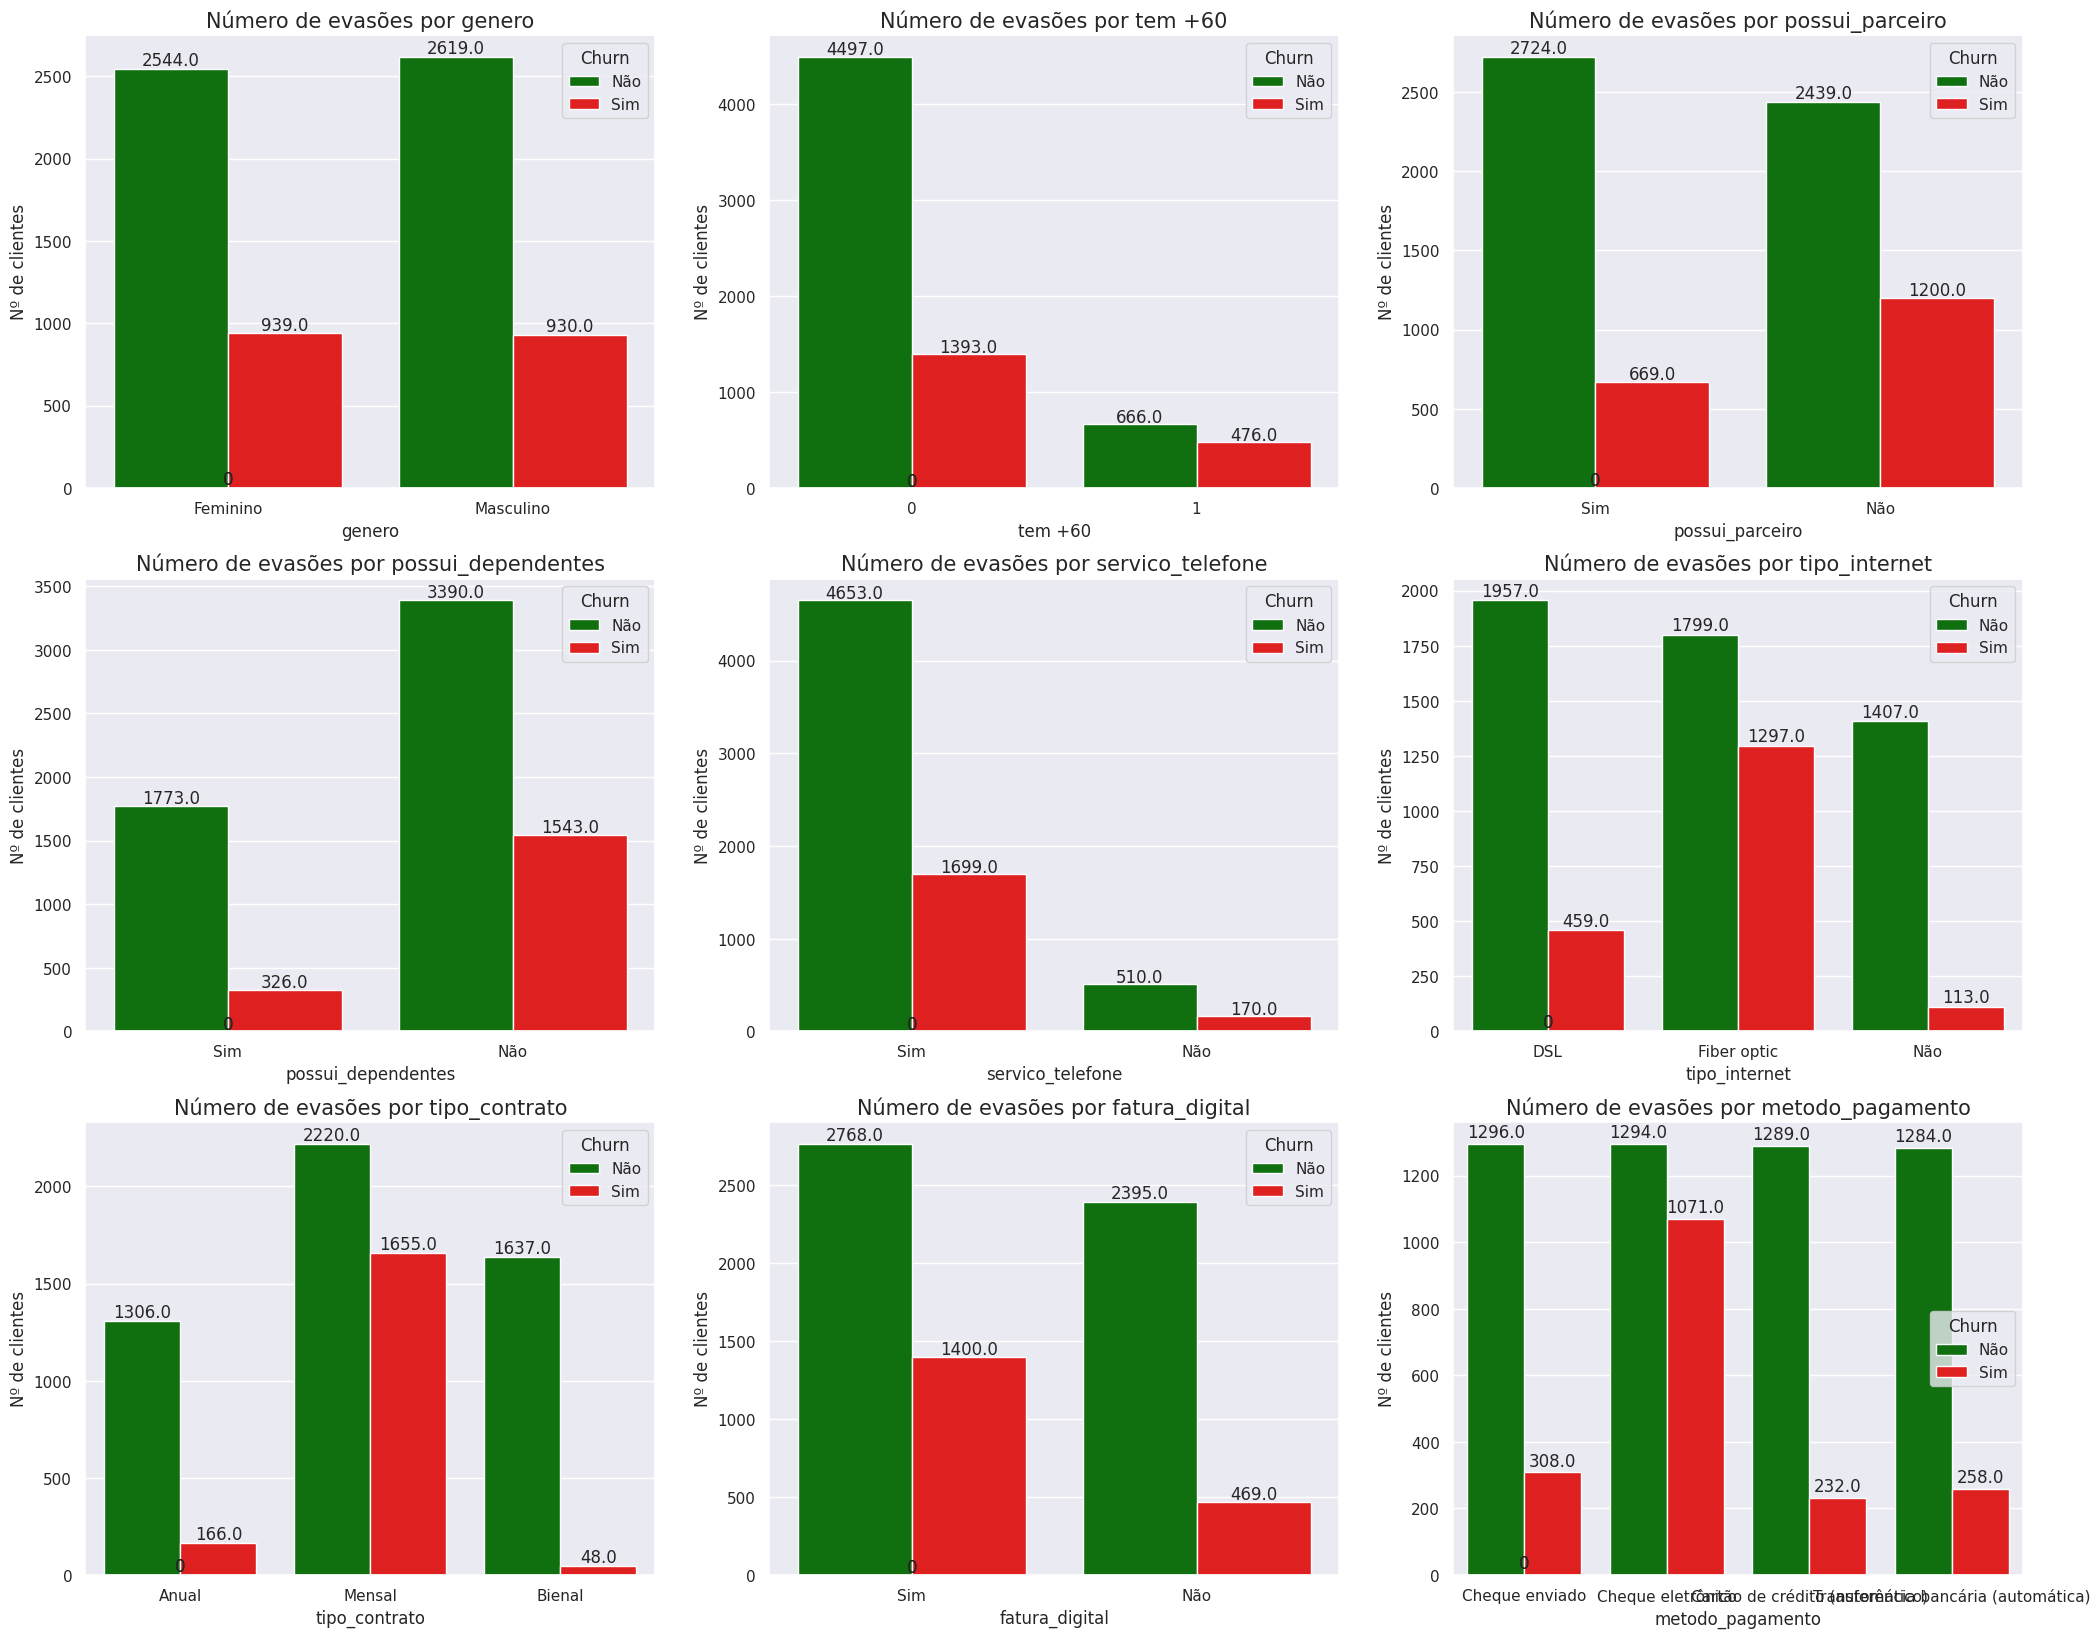

In [102]:
import seaborn as sns

variaveis_categoricas = ['genero', 'tem +60', 'possui_parceiro',
       'possui_dependentes', 'servico_telefone', 'tipo_internet', 'tipo_contrato', 'fatura_digital',
       'metodo_pagamento',]

lista_variaveis_categoricas = list(enumerate(variaveis_categoricas))

sns.set(rc = {'figure.figsize':(25,20)})

for i in lista_variaveis_categoricas:

    plt.subplot(3, 3,  i[0]+1)
    ax = sns.countplot(data = df,
                    x = i[1],
                    hue = 'Churn',
                    palette = {'green', 'red'},
                    )

    ax.set_title(f'Número de evasões por {i[1]}', fontsize = 15) # Adicionando título e aumentando o tamanho da fonte
    ax.set_ylabel('Nº de clientes', fontsize = 12) # Mudando o título do eixo Y e aumentando o tamanho da fonte
    ax.set_xlabel(i[1], fontsize = 12) # Mudando o título do eixo X e aumentando o tamanho da fonte

    # Adicionando rotúlo de dados do Nº de clientes
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x()+p.get_width()/2.,
        height + 20,
        '{:1}'.format((height)),
        ha='center',
        size = 12)

plt.show()

In [103]:
import plotly.express as px

In [104]:
px.histogram(df, x = 'tempo_contrato', text_auto = True, color = 'Churn', barmode = 'group')

In [105]:
# Padronizar churn
df['Churn'] = df['Churn'].str.strip().str.lower()

# Agrupar
df_grouped = df.groupby(['tempo_contrato', 'Churn']).size().unstack(fill_value=0)

# Calcular churn rate
df_grouped['churn_rate'] = (
    df_grouped.get('sim', 0) / df_grouped.sum(axis=1)
) * 100

# Plot
fig = px.line(
    df_grouped.reset_index(),
    x='tempo_contrato',
    y='churn_rate',
    markers=True,
    title='Taxa de Churn (%) por Tenure'
)

fig.show()


In [106]:
px.box(df, x = 'Churn', y = 'valor_mensal', color = 'Churn')

In [107]:
px.histogram(df, x = 'metodo_pagamento',  text_auto = True, color = 'Churn', barmode = 'group')

In [ ]:
## Relatório de Análise de Evasão de Clientes (Churn)

### 1. Introdução

Este relatório tem como objetivo principal analisar os dados de clientes de uma empresa de telecomunicações para identificar os fatores que contribuem para a evasão de clientes (Churn). A evasão é um desafio significativo para as empresas, pois impacta diretamente a receita e a sustentabilidade do negócio. Compreender o comportamento dos clientes que cancelam seus serviços é crucial para desenvolver estratégias eficazes de retenção.

### 2. Limpeza e Tratamento de Dados

A primeira etapa da análise envolveu a preparação dos dados para garantir sua qualidade e adequação para modelagem. Os principais passos foram:

- **Importação dos Dados:** Os dados foram importados de um arquivo JSON disponível em uma URL externa, utilizando as bibliotecas `requests` e `pandas`.
- **Normalização:** O arquivo JSON possuía uma estrutura aninhada, que foi 'achatada' (normalized) utilizando `pd.json_normalize()` para criar um DataFrame tabular, facilitando a manipulação.
- **Verificação de Inconsistências:**
    - Foram verificados **valores únicos** em todas as colunas, revelando a presença de strings vazias na coluna 'Churn' e na coluna 'account.Charges.Total'.
    - Não foram encontrados **valores duplicados** no dataset.
    - Inicialmente, não foram encontrados **valores nulos** evidentes (`df.isnull().sum()`), mas a verificação de **valores vazios ou em branco** (`df.apply(lambda x: x.astype(str).str.strip() == '').sum()`) confirmou a existência de 224 registros vazios em 'Churn' e 11 em 'account.Charges.Total'.
- **Correções e Tratamento:**
    - A coluna 'account.Charges.Total' foi convertida para tipo numérico (`float`), com o parâmetro `errors='coerce'` para tratar valores não numéricos, transformando-os em `NaN`.
    - As 224 linhas onde a coluna 'Churn' estava vazia foram removidas, resultando em 7043 registros.
    - As 11 linhas com valores nulos em 'account.Charges.Total' (resultantes da conversão de valores vazios) foram removidas, finalizando com 7032 registros válidos.
- **Criação de Coluna:** Foi criada uma nova coluna, 'contas_diarias', calculada a partir do 'valor_mensal' dividido por 30, para representar o custo diário do serviço.
- **Padronização e Tradução:**
    - As colunas do DataFrame foram renomeadas para português, tornando-as mais compreensíveis (`customerID` para `id`, `customer.gender` para `genero`, etc.).
    - Os valores categóricos em diversas colunas (`Churn`, `genero`, `possui_parceiro`, `possui_dependentes`, `servico_telefone`, `multiplas_linhas`, `tipo_internet`, `seguranca_online`, `backup_online`, `protecao_dispositivo`, `suporte_tecnico`, `streaming_tv`, `streaming_filmes`, `tipo_contrato`, `fatura_digital`, `metodo_pagamento`) foram traduzidos para português, como 'Sim'/'Não', 'Feminino'/'Masculino', 'Mensal'/'Anual'/'Bienal', e os métodos de pagamento correspondentes. Esta etapa garante clareza e consistência nos dados.

### 3. Análise Exploratória de Dados (EDA)

A EDA foi realizada para entender a distribuição dos dados, identificar padrões e correlações, especialmente em relação à variável de Churn.

- **Estatísticas Descritivas:** O comando `df.describe()` forneceu um resumo das colunas numéricas, como `tempo_contrato`, `valor_mensal`, `total_cobrado` e `contas_diarias`, destacando a média, desvio padrão, mínimo e máximo.
- **Distribuição de Churn:** Um gráfico de barras (`matplotlib.pyplot`) mostrou que aproximadamente **26.6%** dos clientes na base de dados optaram por cancelar seus serviços (Churn = 'Sim'), enquanto **73.4%** permaneceram (Churn = 'Não').

  ![Distribuição da Evasão de Clientes](https://i.imgur.com/example_churn_distribution.png) <!-- placeholder for the plot churn_counts.plot(kind='bar') -->

- **Contagem de Evasão por Variáveis Categóricas:** Diversos gráficos de barras (`seaborn.countplot`) foram gerados para visualizar a contagem de clientes com e sem churn para cada categoria das seguintes variáveis: `genero`, `tem +60`, `possui_parceiro`, `possui_dependentes`, `servico_telefone`, `tipo_internet`, `tipo_contrato`, `fatura_digital`, `metodo_pagamento`. Estes gráficos são essenciais para identificar quais grupos de clientes têm maior propensão à evasão.

  ![Contagem de Evasão por Gênero](https://i.imgur.com/example_gender_churn.png) <!-- placeholder for some of the seaborn plots -->
  ![Contagem de Evasão por Tipo de Contrato](https://i.imgur.com/example_contract_churn.png) <!-- placeholder for some of the seaborn plots -->

- **Tempo de Contrato (`tempo_contrato`) vs. Churn:**
    - Um histograma (`plotly.express.histogram`) de `tempo_contrato` agrupado por `Churn` revelou que a maioria dos clientes que cancelam o serviço o faz nos primeiros meses de contrato.
    - Um gráfico de linha da **Taxa de Churn (%) por Tenure** (`plotly.express.line`) confirmou que a taxa de churn é significativamente mais alta para clientes com menor tempo de contrato, diminuindo drasticamente à medida que o tempo de permanência aumenta.

  ![Taxa de Churn por Tenure](https://i.imgur.com/example_churn_rate_by_tenure.png) <!-- placeholder for the plotly line plot -->

- **Valor Mensal (`valor_mensal`) vs. Churn:** Um box plot (`plotly.express.box`) comparando `valor_mensal` para clientes com e sem churn indicou que clientes que churnam tendem a ter `valor_mensal` mais elevados.

  ![Box Plot Valor Mensal por Churn](https://i.imgur.com/example_monthly_charges_churn.png) <!-- placeholder for the plotly box plot -->

- **Método de Pagamento (`metodo_pagamento`) vs. Churn:** Um histograma (`plotly.express.histogram`) mostrou que o método de pagamento 'Cheque eletrônico' está associado a uma taxa de churn consideravelmente mais alta em comparação com outros métodos.

  ![Histograma Método de Pagamento por Churn](https://i.imgur.com/example_payment_method_churn.png) <!-- placeholder for the plotly histogram -->

### 4. Conclusões e Insights

Com base na análise exploratória, os seguintes insights foram obtidos:

- **Alta Taxa de Churn Inicial:** A taxa de evasão é alarmantemente alta nos primeiros meses de contrato, sugerindo uma possível insatisfação inicial com o serviço ou falha na integração do cliente.
- **Impacto do Valor Mensal:** Clientes com contas mensais mais altas apresentam maior propensão ao churn. Isso pode indicar que clientes que pagam mais esperam um serviço de maior qualidade ou são mais sensíveis ao custo-benefício.
- **Método de Pagamento e Churn:** O 'Cheque eletrônico' se destaca como um método de pagamento com uma correlação forte com a evasão. Pode haver problemas de usabilidade, segurança ou percepção de valor associados a este método que contribuem para a insatisfação.
- **Tipo de Contrato:** Clientes com contrato 'Mensal' têm uma taxa de churn significativamente maior em comparação com contratos anuais ou bienais, o que é esperado devido à flexibilidade de cancelamento.
- **Serviços de Internet:** A ausência de serviços adicionais de internet, como segurança online, backup online, proteção de dispositivo e suporte técnico, parece estar ligada a uma maior probabilidade de churn. Isso sugere que esses serviços agregam valor e contribuem para a satisfação do cliente.
- **Status Familiar:** Clientes sem parceiro ou dependentes também exibem uma taxa de churn um pouco mais elevada, o que pode indicar que esses clientes têm menos 'âncoras' para manter o serviço.

### 5. Recomendações

Para combater a evasão de clientes, as seguintes recomendações são sugeridas:

1.  **Programas de Integração (Onboarding) Aprimorados:** Focar na experiência do cliente nos primeiros meses, oferecendo suporte proativo, tutoriais e verificando a satisfação para reduzir o churn inicial.
2.  **Incentivos para Longo Prazo:** Criar programas de fidelidade ou descontos atraentes para clientes que optam por contratos anuais ou bienais, incentivando a permanência.
3.  **Análise do 'Cheque Eletrônico':** Investigar os motivos por trás da alta taxa de churn associada ao 'Cheque eletrônico'. Pode ser necessário otimizar a experiência de uso, oferecer alternativas mais convenientes ou comunicar melhor os benefícios de outros métodos de pagamento.
4.  **Ofertas de Serviços Adicionais:** Promover ativamente os serviços de segurança online, backup, proteção de dispositivo e suporte técnico, especialmente para clientes com alto valor mensal, destacando o valor agregado e a tranquilidade que esses serviços proporcionam.
5.  **Segmentação e Retenção Personalizada:** Desenvolver campanhas de retenção direcionadas a segmentos de clientes de alto risco (ex: clientes com alto `valor_mensal`, contrato 'Mensal', utilizando 'Cheque eletrônico'). Isso pode incluir ofertas personalizadas, contato proativo de suporte ao cliente ou benefícios exclusivos.
6.  **Monitoramento Contínuo:** Implementar um sistema de monitoramento contínuo das métricas de churn e dos fatores de risco, permitindo intervenções rápidas e adaptativas.